# 00 · Raw signal diagnostics

Open one raw collect and answer one question: **is this recording usable?**

Most "why won't this acquire?" failures are visible here — an AGC set too low or
clipping, real-valued data read as complex, CW interference sitting in the band, or
front-end gain drifting mid-collect.

A *collect* is a directory holding a raw IQ file plus a `metadata.yml` giving the
sample rate, sample format, RF centre frequency and band. Nothing in the raw file
records any of that, which is why the metadata has to travel with it.

**Nothing below will show a satellite, and that is expected.** A GNSS signal
arrives around −157 dBW; spread over the sampled bandwidth its SNR is deeply
negative, tens of dB under the noise floor. Correlation is what recovers it —
despreading collapses the signal's bandwidth while leaving the noise spread, for a
processing gain of roughly `10·log10(T · chip_rate)` (notebook `01`). So the
question here is not "can I see satellites?" but **"is this the right kind of
noise?"**

## 1. Imports

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import numpy.fft as fft
import scipy.signal
import tqdm

import utils
from utils import catalog, collect_metadata_utils, sample_streaming, tables

utils.plotting.setup_default_plotting()  # matplotlib rcParams only

## 2. Choose a channel

One row per band of per collect — a band is what gets processed, so that is the
unit selected here. Pick a row with the two indices in the cell after next.

| Column | |
|---|---|
| `exp`, `ch` | the two indices to set below |
| `Msps` | complex sample rate |
| `fmt` | on-disk format; `sc8` is signed, complex, 8-bit |
| `IF [kHz]` | band centre relative to the centre of the recording, 0 at baseband |

In [2]:
# Runtime config (COLLECTS_PATH etc.) comes from `.env`; see
# utils/environment_variables.py and the README for the template.
collects_dir = utils.environment_variables.get_collects_path()
catalog.print_collect_catalog(collects_dir);

Collects under /Volumes/JX_SSD/Desktop/CU_Boulder/Summer_2026/HERON/COLLECTS:
  exp  experiment                              ch  collect                  band  Msps  fmt  IF [kHz]  dur [s]    GB
  ---  --------------------------------------  --  -----------------------  ----  ----  ---  --------  -------  ----
    0  20210611_121000_011501_HI                0  RX3                      L5    25.0  sc8         0       58   2.9
                                                1  RX5                      L2     5.0  sc8         0      309   3.1
                                                2  RX7                      L1     5.0  sc8         0      600   6.0
    1  20210612_121000_011501_HI                0  RX3                      L5    25.0  sc8         0      120   6.0
                                                1  RX5                      L2     5.0  sc8         0      120   1.2
                                                2  RX7                      L1     5.0  sc8         0  

In [3]:
EXPERIMENT_INDEX = 1  # `exp` column above
CHANNEL_INDEX = 2     # `ch` column, within that experiment

channel = catalog.select_channel(collects_dir, EXPERIMENT_INDEX, CHANNEL_INDEX)
resolved = collect_metadata_utils.resolve_collect(
    collects_dir, channel.experiment_name, channel.collect_id, channel.band_id
)
metadata = resolved.metadata
collect_filepath = resolved.collect_filepath
samp_rate = resolved.samp_rate            # complex sample rate
sample_params = resolved.sample_params    # bit depth, signed, complex, I/Q order
inter_freq_hz = resolved.inter_freq_hz    # band centre within the recording

tables.print_fields(
    [("experiment", channel.experiment_name),
     ("collect / band", f"{channel.collect_id} / {channel.band_id}"),
     ("file", collect_filepath.name),
     ("sample rate", f"{samp_rate / 1e6:.1f} Msps"),
     ("format", catalog.sample_format_label(sample_params)),
     ("intermediate freq", f"{inter_freq_hz / 1e3:,.1f} kHz"),
     ("duration", f"{channel.duration_s:,.1f} s "
                  f"({channel.size_bytes / 1e9:.2f} GB)")],
    caption="Selected:",
)

Selected:
  experiment         20210612_121000_011501_HI
  collect / band     20210612_121000_RX7 / L1
  file               20210612_121000_011501_HI_RX7.sc8
  sample rate        5.0 Msps
  format             sc8
  intermediate freq  0.0 kHz
  duration           120.0 s (1.20 GB)


## 3. Band coverage

A channel records a slice of spectrum `samp_rate` wide, centred on its RF centre
frequency: at baseband on the left, back at RF on the right.

**Check:** each band's centre line sits inside its channel's shaded passband. A
centre line outside the box means that band was not captured, and nothing will
acquire on it.

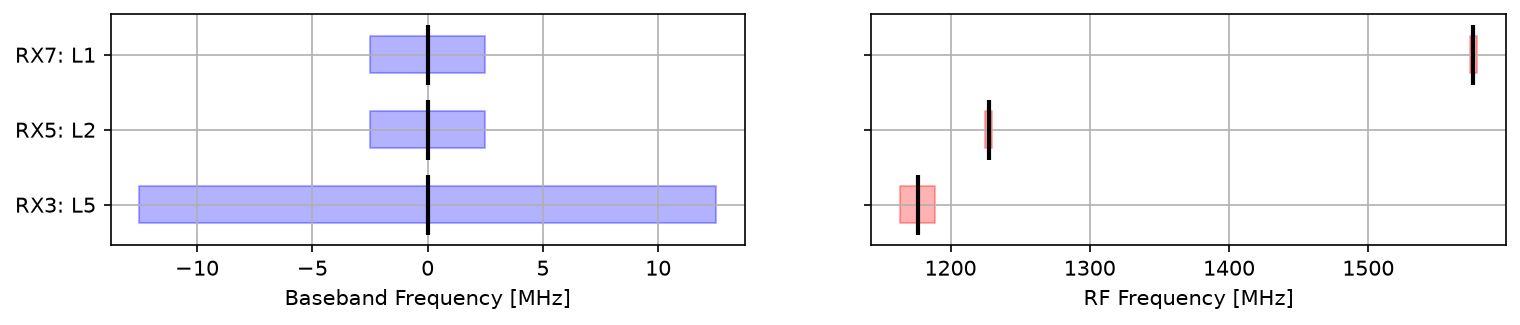

In [4]:
fig = plt.figure(figsize=(12, 2), dpi=150)
utils.plotting.plot_receiver_channel_bands(fig, metadata)

## 4. Read one buffer

Collects run to tens of GB, so read a short buffer from the start. Four steps,
repeated by every notebook downstream:

1. **Read raw bytes** into a pre-sized `bytearray`.
2. **Decode to `complex64`** using `sample_params` — bit depth and layout differ
   per collect, which is why the format is described in metadata, not assumed.
3. **Mix down** by `inter_freq_hz`. A no-op at baseband; leave it in.
4. **Remove DC.** A front-end bias appears as a spike at 0 Hz and biases the
   correlation.

**Parameter:** `buffer_duration_ms` — longer is smoother but slower.

In [5]:
buffer_duration_ms = 100

# Samples and bytes differ: a sample may be complex, and may not be 8 bits.
buffer_size_samples = int(samp_rate * buffer_duration_ms / 1e3)
buffer_size_bytes = sample_streaming.compute_sample_array_size_bytes(
    buffer_size_samples, sample_params.bit_depth, sample_params.is_complex
)
byte_buffer = bytearray(buffer_size_bytes)
sample_buffer = np.zeros(buffer_size_samples, dtype=np.complex64)
baseband_sample_buffer = np.zeros(buffer_size_samples, dtype=np.complex64)

with open(collect_filepath, "rb") as f:
    f.readinto(byte_buffer)

sample_streaming.convert_to_complex64_samples(byte_buffer, sample_buffer, sample_params)

sample_streaming.mixdown_samples(
    sample_buffer,
    baseband_sample_buffer,
    samp_rate,
    0.0,            # initial phase, cycles
    inter_freq_hz,  # frequency to mix off
)

baseband_sample_buffer -= np.mean(baseband_sample_buffer)

## 5. Sample distribution

Histogram of I and Q over the full range the sample format can represent, plus the
I/Q scatter.

**Healthy:** Gaussian, zero-mean, occupying a good fraction of the available range;
a round, featureless scatter.

| Symptom | Cause |
|---|---|
| Flattened against the rails | AGC too high — clipping |
| Confined to a few LSBs | AGC too low; quantisation loss |
| Q identically zero | real-valued data — check `is_complex` in `metadata.yml` |
| Off-centre or annular scatter | residual DC, or an uncorrected carrier offset |

A small spike at one rail is harmless while the bulk of the distribution is well
inside the range. A distribution collapsed into a couple of LSBs is not: that
capture has no dynamic range left and will not acquire.

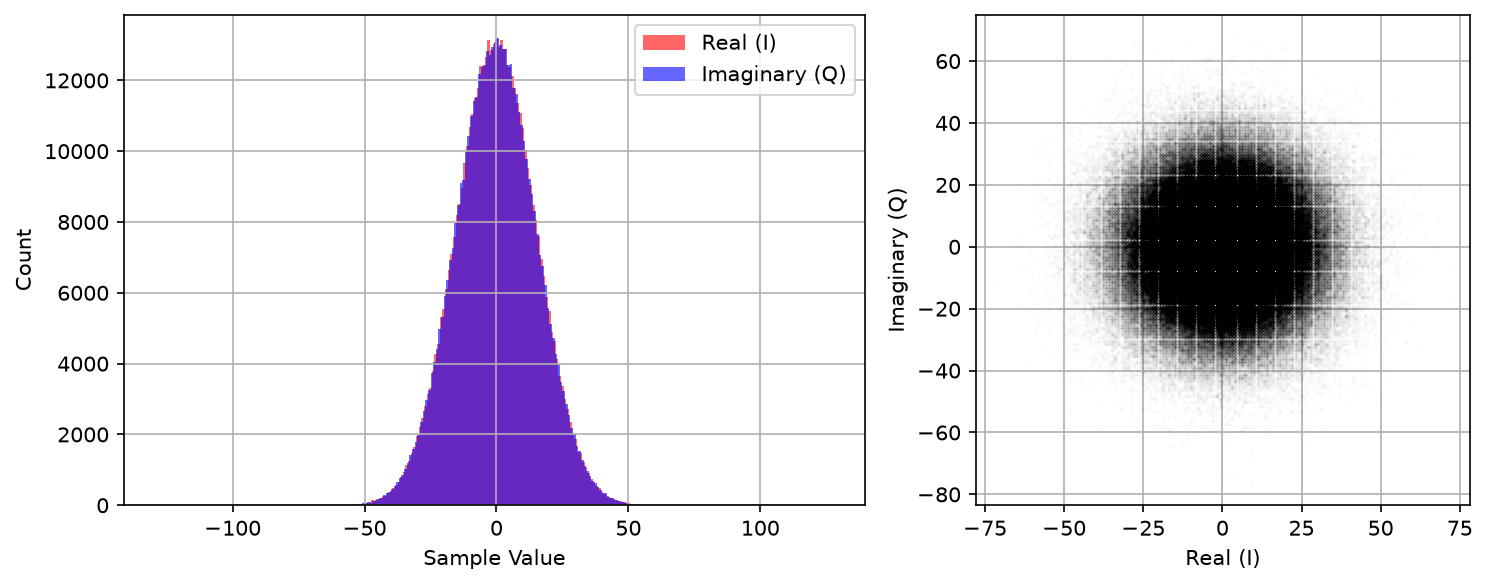

In [6]:
fig = plt.figure(figsize=(10, 4))
utils.plotting.plot_sample_histogram_and_constellation(
    fig, baseband_sample_buffer, bit_depth=sample_params.bit_depth
)
plt.tight_layout()
plt.show()

## 6. Power spectral density

Welch's method — many short periodograms averaged. Grey is the raw capture, black
the mixed-down baseband; they coincide when `inter_freq_hz` is 0.

**Expect** the front end's passband: a broad dome rolling off at the edges. How
much of the span the signal fills depends on the band — a code's main lobe is
±(chip rate) wide, so 1.023 Mcps occupies a narrow centre slice while 10.23 Mcps
fills most of a 20 MHz span.

**Problems:** a narrow spike is CW interference; a flat, domeless trace means the
front end delivered nothing; a spike exactly at 0 MHz is residual DC.

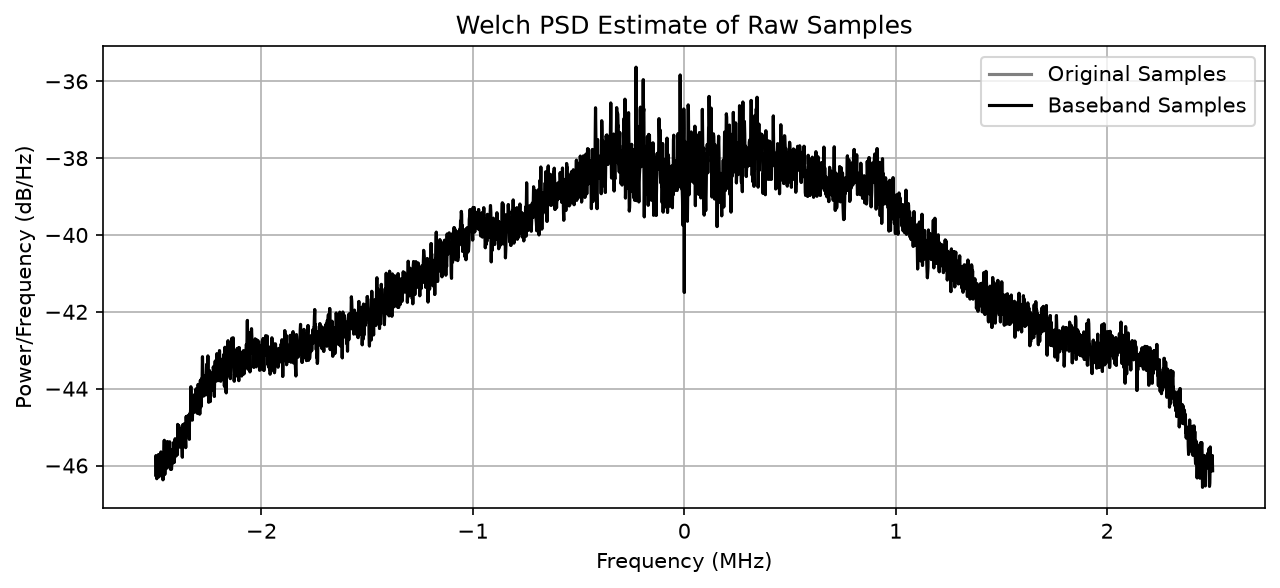

In [7]:
fig = plt.figure(figsize=(10, 4))
utils.plotting.plot_welch_psd(fig, baseband_sample_buffer, samp_rate, sample_buffer)
plt.show()

## 7. Spectrogram over the whole collect

Sections 5–6 saw only the first buffer. Gain drifts, antennas move and interference
comes and goes, so sweep the whole file at one spectrum per second.
`FileSampleStream(..., skip=...)` reads one buffer then jumps the next few,
sampling the file rather than consuming it.

**Parameters:** `stft_interval_ms` (time resolution) and `periodogram_nperseg`
(FFT length — frequency resolution). This is the slow cell; it walks the whole
file.

In [8]:
stft_interval_ms = 1000                               # one spectrum per second
buffer_skip = stft_interval_ms // buffer_duration_ms  # buffers skipped between spectra
periodogram_nperseg = 4096                            # FFT length
periodogram_noverlap = 2048                           # overlap within one Welch estimate
stft_freq = fft.fftshift(fft.fftfreq(periodogram_nperseg, 1 / samp_rate))

# Pre-allocate: estimate the spectrum count from the file size.
file_duration_estimate_ms = (
    os.path.getsize(collect_filepath) // buffer_size_bytes * buffer_duration_ms
)
num_windows = file_duration_estimate_ms // stft_interval_ms
periodogram = np.zeros((num_windows, periodogram_nperseg))

with sample_streaming.FileSampleStream(
    collect_filepath,
    sample_params,
    buffer_size_samples,
) as sample_stream:
    sample_buffer_generator = sample_stream.sample_buffer_generator(skip=buffer_skip)
    # mininterval: a progress bar that redraws many times a second leaves hundreds
    # of separate output chunks in the saved notebook.  Two seconds is still live.
    progress = tqdm.tqdm(sample_buffer_generator, total=num_windows, mininterval=2.0)
    for i, stft_buffer in enumerate(progress):
        _, epoch_psd = scipy.signal.welch(
            stft_buffer,
            fs=samp_rate,
            nperseg=periodogram_nperseg,
            noverlap=periodogram_noverlap,
            window="hann",
            return_onesided=False,
            scaling="density",
        )
        periodogram[i, :] = fft.fftshift(epoch_psd)  # negative frequencies on the left

        if i + 1 == num_windows:
            break

 99%|█████████▉| 119/120 [00:02<00:00, 49.60it/s]


## 8. Reading the spectrogram

Time left to right, frequency bottom to top, colour is power in dB. **Healthy** is
a steady horizontal band, uniform across the capture.

| What you see | What it is |
|---|---|
| Persistent horizontal line | CW interference at a fixed frequency — the most common cause of an otherwise inexplicable acquisition failure |
| Vertical stripes | dropped samples, or a burst of interference |
| Colour drifting over time | AGC or antenna sky view changed during the capture |

Weak CW can be invisible in the histogram and still cost dB at acquisition, so it
is worth looking for a thin bright line spanning the full width even when
everything else looks clean.

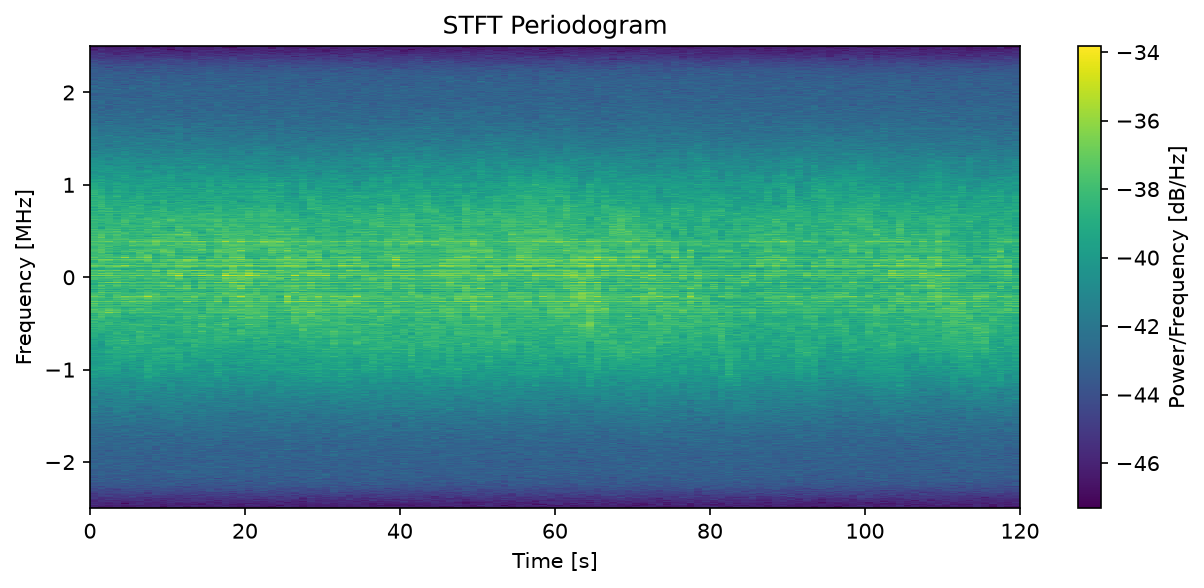

In [9]:
fig = plt.figure(figsize=(10, 4))
utils.plotting.plot_stft_periodogram(
    fig, periodogram, samp_rate, total_duration_s=num_windows * stft_interval_ms / 1e3
)
plt.show()

---

If the collect looks healthy, continue to **`01-acquisition-and-tracking.ipynb`**,
which correlates against each satellite's PRN code and pulls the signals out of
this noise.